# **Variational Autoencoders (VAEs)**

## From Autoencoders to *Variational* Autoencoders

### The Starting Point: Regular Autoencoders

A regular autoencoder is a neural network trained to reconstruct its own input. It has two parts:
- **Encoder**: compresses the input (e.g., a 28x28 image) down to a small vector (e.g., 2 numbers). This small vector is called the **latent representation** and the space it lives in is called the **latent space**.
- **Decoder**: takes that small vector and tries to reconstruct the original image.

After training, the encoder has learned to compress each image to a specific point in the latent space. But there's a problem: **the space *between* those points is meaningless**. If you pick a random point in the latent space that doesn't correspond to a training image, the decoder will produce garbage. The latent space has "holes" — empty regions where the decoder was never trained to produce anything sensible.

This makes regular autoencoders **bad for generation**. They can compress and reconstruct, but they can't synthesize new, plausible images.

### The VAE Insight: Distributions Instead of Points

A Variational Autoencoder fixes this by changing *what* the encoder outputs. Instead of mapping each image to a **single fixed point** in the latent space, the encoder maps each image to a **probability distribution** — specifically, a multivariate normal distribution defined by a mean vector and a variance vector.

Think of it this way: instead of saying "this image of a 7 lives at position (0.5, -0.3) in the latent space," the VAE says "this image of a 7 lives *somewhere around* (0.5, -0.3), with some spread." Each image becomes a little **cloud** rather than a dot.

Why does this help? Three reasons:

1. **Smooth latent space**: Because each image maps to a cloud rather than a point, nearby clouds overlap. The decoder is trained on samples drawn from *all across* these overlapping clouds, so it learns to produce sensible output for the entire region — not just isolated points. The space between training examples becomes meaningful.

2. **Regularization via KL divergence**: The loss function includes a term that pushes every image's distribution toward the standard normal N(0, I). This prevents the encoder from "cheating" by making the clouds infinitely small (which would collapse back to point vectors) or by pushing them far apart into isolated clusters. The result is a well-organized latent space centered around the origin.

3. **Generative capability**: Because the latent space is smooth and centered around N(0, I), we can **generate new images** by simply sampling random points from N(0, I) and feeding them through the decoder. No encoder needed at inference time.

## Training vs. Inference

### During Training (learning the latent space)
1. **Encoder** takes an image and outputs two vectors: a **mean** (μ) and a **log-variance** (log σ²)
2. **Sampling**: we draw a random sample *z* from the normal distribution N(μ, σ²) using the **reparameterization trick** (more on this below)
3. **Decoder** takes *z* and tries to reconstruct the original image
4. **Loss** = reconstruction error + KL divergence (how far the learned distribution is from N(0,1))

The model learns to organize the latent space so that similar images have overlapping distributions.

### During Inference (generating new images)
1. **Throw away the encoder entirely**
2. **Sample** a random vector *z* directly from N(0, I) — the standard normal
3. **Decoder** maps *z* to a new synthetic image

This works because training (via the KL divergence term) ensured that the latent space is organized around N(0, I). Sampling from that distribution at inference time lands us in regions where the decoder knows how to produce coherent images.

## The VAE Loss Function

The total loss has two parts:

### 1. Reconstruction Loss
Measures how well the decoder's output matches the original input. For images with pixel values in [0, 1], we use **binary cross-entropy** summed over all pixels:

$${L}_{\text{recon}} = -\sum_{i=1}^{D} \left[ x_i \log(\hat{x}_i) + (1 - x_i) \log(1 - \hat{x}_i) \right]$$

where $x_i$ is the true pixel value and $\hat{x}_i$ is the reconstructed pixel value. We sum over pixel errors.

### 2. KL Divergence Loss
Measures how far the encoder's output distribution q(z|x) is from the standard normal prior p(z) = N(0, I). For a latent space of dimension *d*:

$${L}_{\text{KL}} = -\frac{1}{2} \sum_{j=1}^{d} \left( 1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2 \right)$$

**Intuition**: if μ = 0 and σ² = 1 (i.e., the encoder maps a n image toward a standard normal distribution, mean 0 and variance 1), every term in this loss is zero. The loss grows when the encoder tries to move away from mean of 0 and variance of 1.

### Total Loss
$${L} = {L}_{\text{recon}} + {L}_{\text{KL}}$$

There is a tension between these two terms. The reconstruction loss wants the encoder to be maximally informative (perfectly encode each image). The KL loss wants all encodings to look like N(0, I). The balance between them is what produces a **smooth, well-organized latent space** that is also good at reconstruction.

## The Reparameterization Trick

There's a subtle problem: we need to **sample** from the distribution N(μ, σ²) during training, but sampling is a random operation that we can't backpropagate through — gradients can't flow through a random number generator.

The solution is the **reparameterization trick**: instead of sampling *z* directly from N(μ, σ²), we:
1. Sample ε from N(0, 1) — a fixed, parameter-free distribution
2. Compute z = μ + σ · ε

This is mathematically identical (z still follows N(μ, σ²)), but now z is a *deterministic function* of μ, σ, and ε. The randomness is isolated in ε, and gradients can flow through the μ and σ parameters during backpropagation. You'll see this implemented in the `sample()` function below.

Notice that E[z] = μ + σ x E[ε]. Recall that μ and σ are constants here. Since E[ε] is 0, i.e., the mean of the N(0,1), we are left with just μ. Further, notice that Var(z) = Var(μ + σ x N(0, 1)) = σ^2 * Var(N(0,1)) = σ^2 (Note: we apply two rules here; first, Var(aX) = a^2 x Var(X) if a is a constant, and second Var(X + c) = Var(X) if c is a constant. So, z ends up being a random draw from N(μ,σ^2)!

# *Build the VAE Model*

The model has three parts:
- **Encoder**: Conv layers compress the 28x28 image, then two Dense heads output the mean (z_mean) and log-variance (z_log_var) vectors — these parameterize the latent distribution for each input image
- **Sampling layer**: applies the reparameterization trick to draw a latent vector z
- **Decoder**: transposed convolutions expand z back to a 28x28 image

In [5]:
import keras
from keras import layers, Model, ops
import numpy as np

latent_dim = 2

# ----- Encoder -----
encoder_input = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(encoder_input)
x = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation='relu')(x)

z_mean = layers.Dense(latent_dim, name='z_mean')(x)

# Note, we have the network produce the log of variance because, taking the exponent, we always get a positive value.
# It would make no sense for the model to be able to produce a negative variance.
z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)

# Stack mean and log_var layer outputs, so we can use them in the KL loss component later (we will push mean 0, log_var = 0)
kl_params = layers.Concatenate(name='kl_params')([z_mean, z_log_var])

# ----- Sampling (reparameterization trick) -----
def sample(args):
    z_mean, z_log_var = args
    epsilon = keras.random.normal(shape=ops.shape(z_mean))

    # Note, we are applying a log rule here: a * log(b) = log(b^a)
    # So, 0.5 * log(sigma^2) = log(sigma^2^1/2) = log(sigma).
    # Then e^log(sigma) = sigma.
    # Thus, we get u + sigma * N(0,1)
    return z_mean + ops.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sample, name='z')([z_mean, z_log_var])

# ----- Decoder (built as its own Model) -----
decoder_input = layers.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation='relu')(decoder_input)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)
x = layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(x)

# Produce a grayscale image as output
decoder_output = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)
decoder = Model(decoder_input, decoder_output, name='decoder')

# ----- Full VAE: encoder -> sampling -> decoder -----
reconstruction = decoder(z)

# Rename the output layer so we can refer to it in compile()
reconstruction = layers.Lambda(lambda t: t, name='reconstruction')(reconstruction)

# We have two output layers.
# One output is the image we generate.
# The other is the mean and log_variance values from the encoded space.
vae = Model(encoder_input, [reconstruction, kl_params])

# ----- Loss functions -----
def kl_loss_fn(y_true, y_pred):

    # Take the first value
    z_mean = y_pred[:, :latent_dim]

    # Take the second value
    z_log_var = y_pred[:, latent_dim:]

    # Calculate a constant (ignore it) * -1 * [- sigma + log(sigma^2) - u^2 + 1]
    # If we have mean 0 and sigma 1, the loss will be zero.
    # As u moves away from 0, we penalize.
    # As sigma moves away from 1, we penalize too.
    # Notice: if sigma >> 1 then -1 * -1 * sigma is in our loss... big positive value.
    # Notice again: if sigma < 1 (a fraction), as we move away from 1 toward 0, we get -Infinity, * -1, a big positive number again.

    # Note: canonical VAE uses -0.5, as that aligns with the properties of standard normal distributions.
    # This is Beta-VAE; I've upweighted the KL term by 5x to more strongly enforce unit normals.
    return -2.5 * ops.mean(
        1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var)
    )

# Notice as well that we sum over pixel error rather than averaging...
# this gives a lot more weight to the image output than to the KL divergence.
def reconstruction_loss_fn(y_true, y_pred):
    bce = keras.losses.binary_crossentropy(y_true, y_pred)  # shape: (batch, 28, 28)
    return ops.mean(ops.sum(bce, axis=(1, 2)))              # sum over pixels, mean over batch

vae.compile(
    optimizer='adam',
    loss={'reconstruction': reconstruction_loss_fn,
          'kl_params': kl_loss_fn}
)

# *Train the VAE*

We train on MNIST — 70,000 handwritten digit images. The model receives each image and must reconstruct it, while the KL loss simultaneously shapes the latent space.

Notice the two loss values reported during training:
- **reconstruction_loss**: how well the decoder recreates the input (should decrease)
- **kl_params_loss**: how close the latent distributions are to N(0,1) (starts low, rises a bit as the encoder learns to use the space, then stabilizes)

In [6]:
import numpy as np
from keras import datasets

(x_train, _), (x_test, _) = datasets.mnist.load_data()

# Use all the data, both train and test together, for training.
mnist_digits = np.concatenate([x_train, x_test], axis=0)

# Add a channel (color) dimension, so the Conv2D layer gets the shape it expects, and scale pixels by 255.
mnist_digits = np.expand_dims(mnist_digits, -1).astype("float32") / 255

# Provide a dummy zero tensor as the "target" for the KL output (it's not actually used in the loss calculation we defined earlier)
dummy_kl_target = np.zeros((len(mnist_digits), latent_dim * 2))

# The images are both the features and the label for reconstruction loss.
vae.fit(mnist_digits, {'reconstruction': mnist_digits, 'kl_params': dummy_kl_target},
        epochs=30, batch_size=128)

Epoch 1/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - kl_params_loss: 3.3800 - loss: 214.4140 - reconstruction_loss: 211.0297
Epoch 2/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_params_loss: 7.9946 - loss: 184.6901 - reconstruction_loss: 176.6939
Epoch 3/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_params_loss: 10.0018 - loss: 174.7240 - reconstruction_loss: 164.7212
Epoch 4/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_params_loss: 10.7728 - loss: 170.7183 - reconstruction_loss: 159.9468
Epoch 5/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_params_loss: 11.2023 - loss: 168.3254 - reconstruction_loss: 157.1231
Epoch 6/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_params_loss: 11.4491 - loss: 166.9943 - reconstruction_loss: 155.5466
Epoch 7/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_params_loss: 11.6218 - loss: 165.8627 - reconstruction_loss: 154.2407
Epoch 8/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_params_loss: 11.8470 - loss: 164.9317 - reconstruction_

# *Exploring the Latent Space*

Now we do something a regular autoencoder *cannot* do: we **systematically walk through the 2D latent space** and decode at each point. Because our latent space is 2-dimensional, we can create a grid of (z₁, z₂) values ranging from -1 to 1, feed each point through the decoder, and display the resulting image.

If the VAE worked, we should see:
- **Smooth transitions** between digit types as we move across the space
- **No garbage regions** — every point in the grid produces something recognizable
- **Meaningful organization** — similar digits cluster together, and the transitions between clusters are gradual

This is the payoff of using distributions instead of points. The entire region around N(0, I) has been "covered" during training, so the decoder knows what to do everywhere.

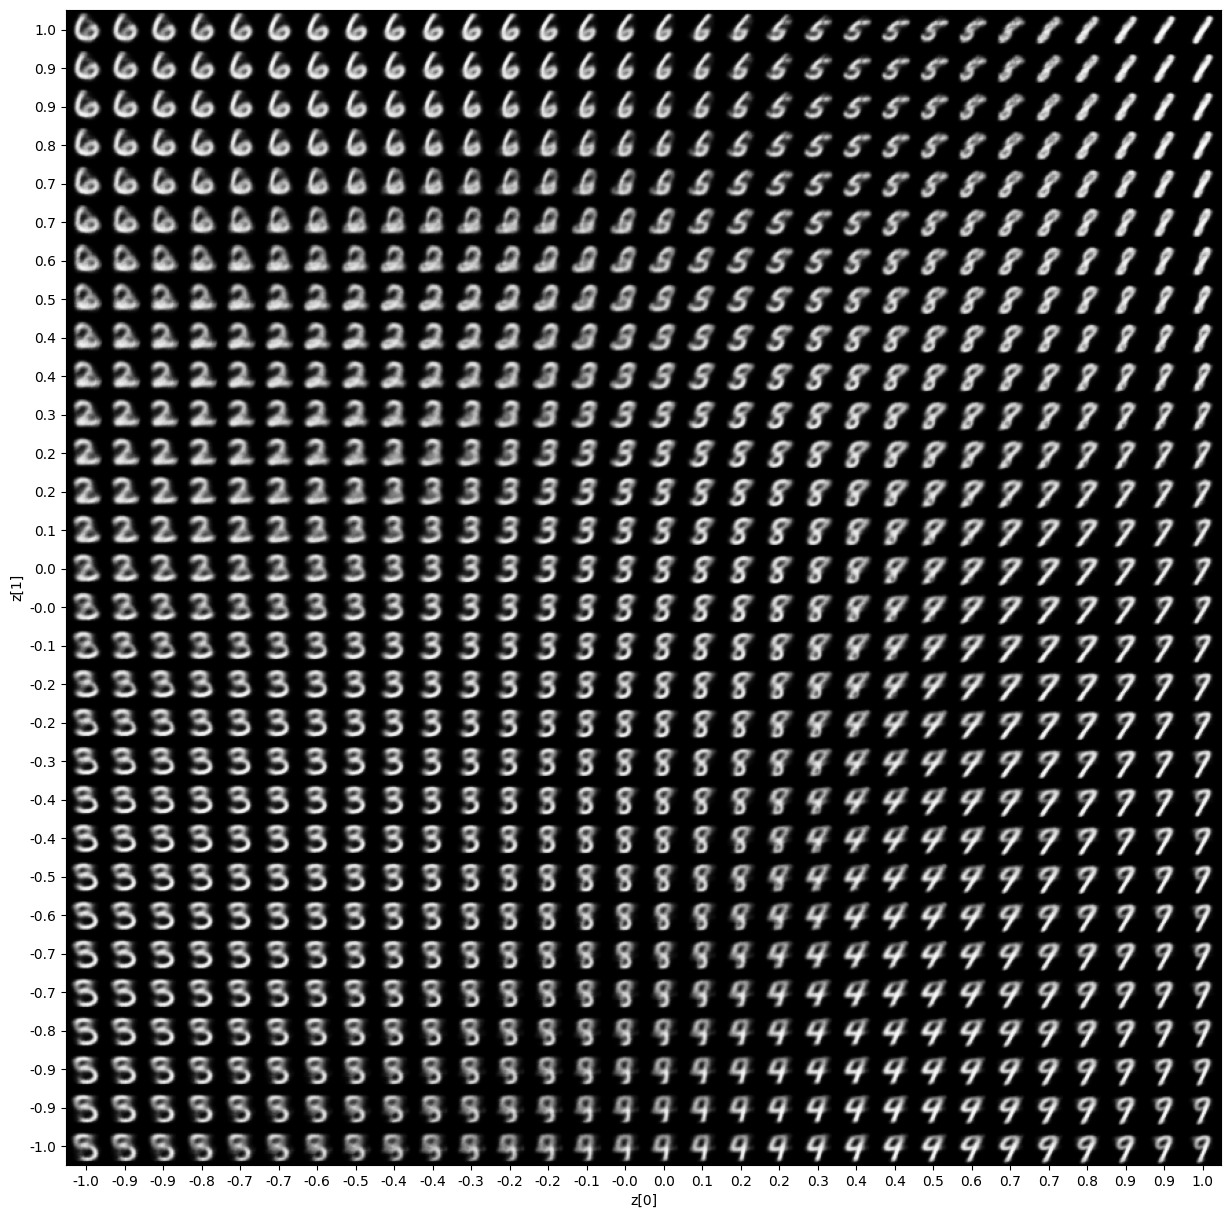

In [7]:
import matplotlib.pyplot as plt

n = 30
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

grid_x = np.linspace(-1, 1, n)
grid_y = np.linspace(-1, 1, n)[::-1]

# Now we are just going to traverse the latent space, from -1 to 1, over the bivariate latent space.
for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder.predict(z_sample, verbose=0)

        # Matplotlib doesn't expect the color channel here, so we are reshaping to drop it.
        digit = x_decoded[0].reshape(digit_size, digit_size)

        #We are building one giant figure, stitching together image predictions as components (we're making a quilt)
        figure[
            i * digit_size : (i + 1) * digit_size,
            j * digit_size : (j + 1) * digit_size,
        ] = digit

plt.figure(figsize=(15, 15))
start_range = digit_size // 2
end_range = n * digit_size + start_range
pixel_range = np.arange(start_range, end_range, digit_size)
sample_range_x = np.round(grid_x, 1)
sample_range_y = np.round(grid_y, 1)
plt.xticks(pixel_range, sample_range_x)
plt.yticks(pixel_range, sample_range_y)
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.imshow(figure, cmap="Greys_r")
plt.show()

## What the Grid Shows

The grid above is a map of the decoder's output across the 2D latent space. Each small image was generated by feeding a specific (z₁, z₂) coordinate through the decoder — **no real images were used**.

Notice how digits morph smoothly into each other as you move through the space. A region of 1s gradually transitions into 7s; 0s blend into 6s or 9s. There are no sharp boundaries or meaningless dead zones. This is exactly what the KL divergence term bought us — by forcing the encoder's distributions to overlap with N(0, I), the entire central region of the latent space produces coherent digits.

**This is what makes VAEs generative models**: we can sample *any* point from this space and get a plausible digit. We are no longer limited to reconstructing images we've already seen — we can synthesize entirely new ones.

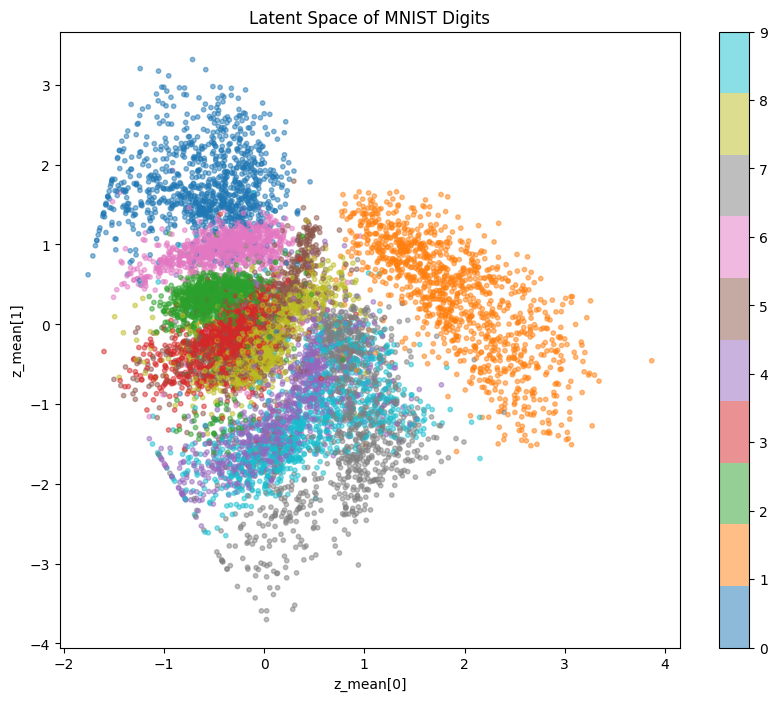

In [8]:
import matplotlib.pyplot as plt

# We need just the encoder to get the z_mean values
encoder = Model(encoder_input, z_mean, name='encoder')

# Get the latent representations for the test set
z_mean_test = encoder.predict(x_test.reshape(-1, 28, 28, 1).astype('float32') / 255, verbose=0)

# Plot the representations
plt.figure(figsize=(10, 8))
scatter = plt.scatter(z_mean_test[:, 0], z_mean_test[:, 1], c=_, cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, ticks=range(10))
plt.xlabel("z_mean[0]")
plt.ylabel("z_mean[1]")
plt.title("Latent Space of MNIST Digits")
plt.show()